# Notebook 3 — Generalization
### Gradient Autopsy · Phase 2 (part 2)

This notebook cures the second failure from Notebook 1 — overfitting (the +0.108 train/test gap).
We apply the generalization toolkit and measure each fix: dropout, L2 weight decay, early stopping,
data augmentation, and finally transfer learning from a pretrained ResNet-18. All shared
infrastructure is loaded from `common.py`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive"   # common.py reads this to know where to save results

Mounted at /content/drive


In [2]:
import shutil
shutil.copytree("/content/drive/MyDrive/cifar_data/data", "./data", dirs_exist_ok=True)
print("CIFAR restored from Drive ✓")

CIFAR restored from Drive ✓


In [3]:
%run /content/drive/MyDrive/gradient_autopsy_common.py

# Confirm the GPU is actually attached (warns loudly if not).
if device.type == "cuda":
    print(f" GPU active: {torch.cuda.get_device_name(0)}")
else:
    print("  NO GPU! Fix: Runtime → Change runtime type → T4 GPU, then re-run these cells.")

[common] Loaded: CONFIG, set_seed, device, loaders, FragileCNN, train_and_instrument, plot_gradient_heatmap, MLP, SmallCNN, train_timed
[common] device=cuda  RESULTS_DIR=./gradient_autopsy_results
✅ GPU active: Tesla T4


## C14 · Regularization — shrinking the overfitting gap

Notebook 1 (C8) showed a capable CNN overfitting the 4,000-image subset: train accuracy pulled far
above test accuracy (gap ≈ +0.108). Here we apply the three classic regularizers and measure how much
each closes that gap:

- **Dropout** — randomly zero a fraction of neurons during training, forcing redundant, robust features.
- **L2 weight decay** — penalize large weights (passed as `weight_decay` to the optimizer), favoring
  smoother functions that generalize.
- **Early stopping** — stop when test accuracy stops improving, before the model starts memorizing.

Trained on the **same fixed 4,000-image subset** as C8 so only the regularization changes. The goal is
a **smaller train/test gap** without sacrificing test accuracy.

In [4]:
# A capable CNN with an adjustable dropout switch (same style as the C8 overfitter).
class RegCNN(nn.Module):
    def __init__(self, width=64, num_classes=10, dropout=0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, width, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),      # 32->16
            nn.Conv2d(width, width, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 16->8
            nn.Conv2d(width, width, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 8->4
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        # Dropout sits in the classifier head; p=0 => no-op (the baseline).
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(width, num_classes),
        )
    def forward(self, x):
        return self.head(self.pool(self.features(x)))


def train_reg(model, epochs=25, lr=1e-3, weight_decay=0.0, patience=None, log_every=5):
    """Train on the fixed small subset, tracking train/test accuracy.
    weight_decay>0 turns on L2. patience=N enables early stopping (stop after N epochs
    with no test-accuracy improvement). Prints every `log_every` epochs."""
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    hist = {"train_acc": [], "test_acc": []}
    best_acc, wait = 0.0, 0

    for ep in range(epochs):
        model.train()
        for X, y in small_train_loader:          # the fixed 4,000-image subset
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            criterion(model(X), y).backward()
            optimizer.step()

        _, tr = evaluate(model, small_train_loader)
        _, te = evaluate(model, test_loader)
        hist["train_acc"].append(tr)
        hist["test_acc"].append(te)

        if (ep + 1) % log_every == 0 or ep == epochs - 1:
            print(f"  epoch {ep+1:>2}/{epochs}: train {tr:.3f} | test {te:.3f} | gap {tr-te:+.3f}")

        # early stopping: stop if test acc hasn't improved for `patience` epochs
        if patience is not None:
            if te > best_acc:
                best_acc, wait = te, 0
            else:
                wait += 1
                if wait >= patience:
                    print(f"  early stop at epoch {ep+1} (no improvement for {patience} epochs)")
                    break
    return hist

In [5]:
# Compare: baseline (no reg) vs dropout vs weight decay vs both.
reg_configs = {
    "baseline":      dict(dropout=0.0, weight_decay=0.0),
    "dropout":       dict(dropout=0.5, weight_decay=0.0),
    "weight_decay":  dict(dropout=0.0, weight_decay=1e-3),
    "both":          dict(dropout=0.5, weight_decay=1e-3),
}

reg_hist = {}
for name, cfg in reg_configs.items():
    print(f"[{name}]")
    set_seed(CONFIG["seed"])
    model = RegCNN(dropout=cfg["dropout"])
    reg_hist[name] = train_reg(model, epochs=25, weight_decay=cfg["weight_decay"])
    print()

# Summary: final gap per technique.
print(f"{'Config':<14}{'Train':>8}{'Test':>8}{'Gap':>8}")
print("-" * 38)
for name, h in reg_hist.items():
    gap = h["train_acc"][-1] - h["test_acc"][-1]
    print(f"{name:<14}{h['train_acc'][-1]:>8.3f}{h['test_acc'][-1]:>8.3f}{gap:>+8.3f}")

[baseline]
  epoch  5/25: train 0.431 | test 0.411 | gap +0.020
  epoch 10/25: train 0.511 | test 0.465 | gap +0.046
  epoch 15/25: train 0.555 | test 0.487 | gap +0.068
  epoch 20/25: train 0.622 | test 0.533 | gap +0.089
  epoch 25/25: train 0.648 | test 0.541 | gap +0.107

[dropout]
  epoch  5/25: train 0.371 | test 0.363 | gap +0.008
  epoch 10/25: train 0.458 | test 0.428 | gap +0.029
  epoch 15/25: train 0.503 | test 0.467 | gap +0.036
  epoch 20/25: train 0.540 | test 0.484 | gap +0.056
  epoch 25/25: train 0.564 | test 0.514 | gap +0.050

[weight_decay]
  epoch  5/25: train 0.425 | test 0.407 | gap +0.018
  epoch 10/25: train 0.491 | test 0.449 | gap +0.042
  epoch 15/25: train 0.521 | test 0.465 | gap +0.056
  epoch 20/25: train 0.592 | test 0.522 | gap +0.070
  epoch 25/25: train 0.617 | test 0.530 | gap +0.087

[both]
  epoch  5/25: train 0.355 | test 0.358 | gap -0.003
  epoch 10/25: train 0.437 | test 0.418 | gap +0.019
  epoch 15/25: train 0.482 | test 0.450 | gap +0.031


Early stopping demo (baseline model, patience=5):
  epoch  5/40: train 0.430 | test 0.410 | gap +0.020
  epoch 10/40: train 0.512 | test 0.459 | gap +0.053
  epoch 15/40: train 0.542 | test 0.476 | gap +0.066
  epoch 20/40: train 0.625 | test 0.538 | gap +0.087
  epoch 25/40: train 0.656 | test 0.548 | gap +0.108
  epoch 30/40: train 0.678 | test 0.553 | gap +0.125
  epoch 35/40: train 0.707 | test 0.556 | gap +0.151
  epoch 40/40: train 0.710 | test 0.539 | gap +0.171


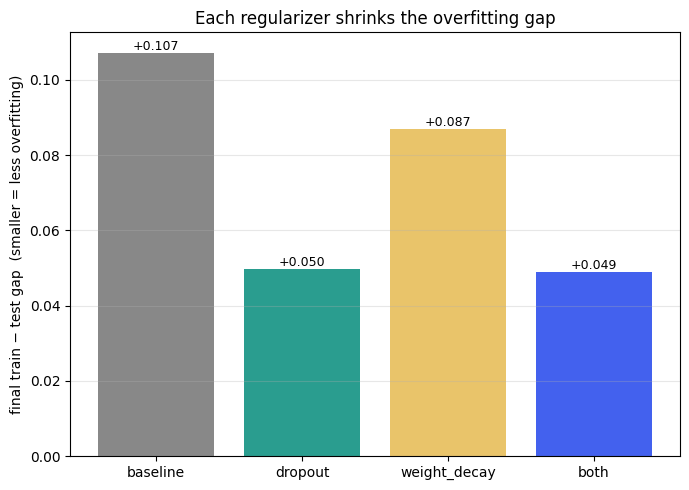

In [6]:
import numpy as np

# Early stopping shown separately: train the baseline with patience and watch it stop early.
print("Early stopping demo (baseline model, patience=5):")
set_seed(CONFIG["seed"])
es_model = RegCNN(dropout=0.0)
es_hist = train_reg(es_model, epochs=40, patience=5)

# Save the regularization results for the synthesis notebook.
for name, h in reg_hist.items():
    np.save(f"{RESULTS_DIR}/reg_{name}_train.npy", np.array(h["train_acc"]))
    np.save(f"{RESULTS_DIR}/reg_{name}_test.npy",  np.array(h["test_acc"]))

# Bar chart: final train/test gap per technique (smaller = better).
gaps = [reg_hist[n]["train_acc"][-1] - reg_hist[n]["test_acc"][-1] for n in reg_configs]
plt.figure(figsize=(7, 5))
bars = plt.bar(list(reg_configs.keys()), gaps, color=["#888", "#2a9d8f", "#e9c46a", "#4361ee"])
plt.ylabel("final train − test gap  (smaller = less overfitting)")
plt.title("Each regularizer shrinks the overfitting gap")
plt.grid(True, axis="y", alpha=0.3)
for bar, g in zip(bars, gaps):
    plt.text(bar.get_x()+bar.get_width()/2, g, f"{g:+.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/c14_regularization.png", dpi=120)
plt.show()

### C14 · Concept check (interview-level)

**Q1. Dropout more than halved the gap; weight decay barely helped and added almost nothing on top of dropout. Why might dropout dominate weight decay here?**

It comes down to *where* each regularizer acts and where this network's capacity lives. Dropout was
placed in the classifier head, right before the final linear layer — the point of highest overfitting
pressure, where the pooled features get mapped to class scores on only 4,000 images. By randomly
zeroing half those features each step, it forces the classifier to not rely on any single feature,
which directly attacks memorization at the decision layer. L2 weight decay, by contrast, applies a
uniform small penalty to *all* weights, including the convolutional filters — but conv layers already
have very few parameters (weight sharing), so they weren't the main source of overfitting, and
penalizing them yields little. On a small dataset with a convolutional feature extractor, the
memorization bottleneck is the dense head, which is exactly what dropout targets and weight decay only
diffusely touches. Hence dropout dominates, and once dropout has removed most of the head's
memorization, weight decay has little left to improve — which is why "both" ≈ "dropout alone."

**Q2. If you forgot `model.eval()` and ran inference with dropout still on, would predictions be biased or just noisy?**

Just **noisy**, not biased — because of how PyTorch implements dropout ("inverted dropout"). During
training, dropout zeros a fraction p of activations *and scales the survivors by 1/(1−p)*, so the
expected value of each activation is preserved. That means at inference with dropout accidentally on,
each forward pass randomly drops a different subset but the *expected* output still matches the
train-time distribution — predictions won't be systematically shifted in one direction. What you lose
is determinism and accuracy: every forward pass gives a slightly different answer, and single-pass
accuracy drops because you're throwing away half the signal each time. (Interestingly, averaging many
such stochastic passes is exactly Monte-Carlo Dropout, used for uncertainty estimation — the same
"bug" turned into a feature.) So: unbiased in expectation, but noisy and less accurate per pass.

**Q3. Test accuracy peaked at epoch ~35 then declined. Why is early stopping better than just always training fewer epochs?**

Because the peak epoch is not known in advance and is not fixed — it depends on the dataset size,
the model, the learning rate, the regularization, and even the random seed. A fixed "train for N
epochs" rule is a guess that will be wrong for any configuration different from the one you tuned it
on: too few epochs and you underfit (stop before the peak); too many and you overfit (sail past it,
like this run reaching epoch 40 with a +0.171 gap). Early stopping *adapts* — it watches validation
performance and stops at the actual peak for *this* run, wherever it falls. It turns "guess the right
duration" into "detect the right duration," which generalizes across experiments. The one requirement
is a held-out validation signal to monitor; a fixed epoch count has no feedback and cannot react to
the curve it's actually producing.

## C15 · Data Augmentation — fighting overfitting from the data side

C14 fought overfitting from the *model* side (dropout, weight decay). Augmentation fights it from the
*data* side: by applying random label-preserving transforms (horizontal flips, random crops) to the
training images, the model never sees the exact same image twice, so it can't memorize pixel-level
specifics — it's forced to learn the underlying object.

We rebuild the **same fixed 4,000-image subset**, but now with the augmentation pipeline
(`augment_transform` from `common.py`) applied to the training data. The test set stays on the plain
transform — **you never augment test data**, because you want to measure real performance, not
performance on distorted images.

Expected: train accuracy drops (harder to memorize augmented data) but test accuracy holds or
improves, so the train/test gap shrinks — the same goal as C14, achieved a different way.

In [7]:
import torchvision
from torch.utils.data import DataLoader, Subset

# Rebuild the SAME 4,000-image subset, but with the augmentation transform applied.
# We reuse the exact same indices (fixed generator) so only the transform differs.
aug_full = torchvision.datasets.CIFAR10(
    root=CONFIG["data_root"], train=True, download=False, transform=augment_transform)

subset_gen = torch.Generator().manual_seed(CONFIG["seed"])          # same seed as common.py's subset
subset_idx = torch.randperm(len(aug_full), generator=subset_gen)[:CONFIG["small_subset_size"]]
aug_small = Subset(aug_full, subset_idx.tolist())
aug_small_loader = DataLoader(aug_small, batch_size=CONFIG["batch_size"], shuffle=True)

print(f"Augmented subset: {len(aug_small)} images (same indices as the plain subset, flips+crops applied)")


def train_on_loader(model, train_loader, epochs=25, lr=1e-3, log_every=5):
    """Train on a given loader, tracking train/test accuracy each epoch.
    Train accuracy is measured on the PLAIN small subset (not the augmented one),
    so the train/test gap is an apples-to-apples comparison."""
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    hist = {"train_acc": [], "test_acc": []}
    for ep in range(epochs):
        model.train()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            criterion(model(X), y).backward()
            optimizer.step()
        _, tr = evaluate(model, small_train_loader)   # evaluate on PLAIN subset for fair gap
        _, te = evaluate(model, test_loader)
        hist["train_acc"].append(tr)
        hist["test_acc"].append(te)
        if (ep + 1) % log_every == 0 or ep == epochs - 1:
            print(f"  epoch {ep+1:>2}/{epochs}: train {tr:.3f} | test {te:.3f} | gap {tr-te:+.3f}")
    return hist


# Baseline (no augmentation) — reuse the RegCNN from C14.
print("No augmentation (baseline):")
set_seed(CONFIG["seed"])
noaug_model = RegCNN(dropout=0.0)
noaug_hist = train_on_loader(noaug_model, small_train_loader, epochs=25)

print("\nWith augmentation (flips + crops):")
set_seed(CONFIG["seed"])
aug_model = RegCNN(dropout=0.0)
aug_hist = train_on_loader(aug_model, aug_small_loader, epochs=25)

Augmented subset: 4000 images (same indices as the plain subset, flips+crops applied)
No augmentation (baseline):
  epoch  5/25: train 0.430 | test 0.408 | gap +0.022
  epoch 10/25: train 0.502 | test 0.454 | gap +0.048
  epoch 15/25: train 0.538 | test 0.474 | gap +0.064
  epoch 20/25: train 0.625 | test 0.531 | gap +0.095
  epoch 25/25: train 0.652 | test 0.543 | gap +0.109

With augmentation (flips + crops):
  epoch  5/25: train 0.386 | test 0.366 | gap +0.020
  epoch 10/25: train 0.458 | test 0.431 | gap +0.027
  epoch 15/25: train 0.469 | test 0.440 | gap +0.029
  epoch 20/25: train 0.539 | test 0.498 | gap +0.040
  epoch 25/25: train 0.560 | test 0.501 | gap +0.059


Final gap — no augmentation: +0.109
Final gap — augmentation:    +0.059
Final test acc — no aug: 0.543 | aug: 0.501


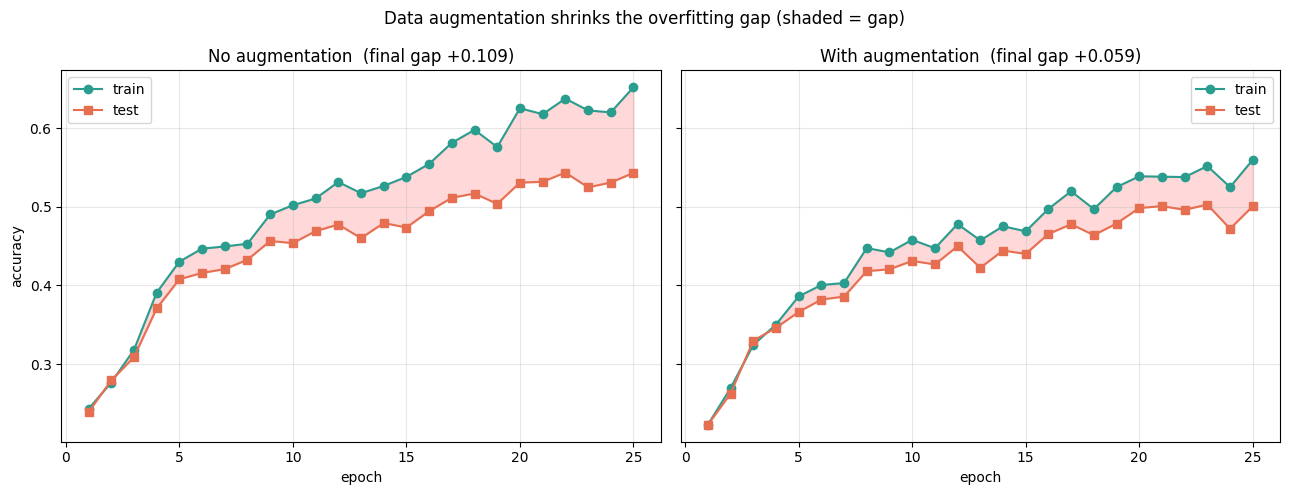

In [8]:
import numpy as np

# Save for the synthesis notebook.
np.save(f"{RESULTS_DIR}/aug_off_train.npy", np.array(noaug_hist["train_acc"]))
np.save(f"{RESULTS_DIR}/aug_off_test.npy",  np.array(noaug_hist["test_acc"]))
np.save(f"{RESULTS_DIR}/aug_on_train.npy",  np.array(aug_hist["train_acc"]))
np.save(f"{RESULTS_DIR}/aug_on_test.npy",   np.array(aug_hist["test_acc"]))

noaug_gap = noaug_hist["train_acc"][-1] - noaug_hist["test_acc"][-1]
aug_gap   = aug_hist["train_acc"][-1]   - aug_hist["test_acc"][-1]
print(f"Final gap — no augmentation: {noaug_gap:+.3f}")
print(f"Final gap — augmentation:    {aug_gap:+.3f}")
print(f"Final test acc — no aug: {noaug_hist['test_acc'][-1]:.3f} | aug: {aug_hist['test_acc'][-1]:.3f}")

# Two-panel plot: train/test curves with the gap shaded, side by side.
epochs_range = range(1, 26)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, hist, title in [(axes[0], noaug_hist, "No augmentation"),
                        (axes[1], aug_hist,   "With augmentation")]:
    ax.plot(epochs_range, hist["train_acc"], "o-", label="train", color="#2a9d8f")
    ax.plot(epochs_range, hist["test_acc"],  "s-", label="test",  color="#e76f51")
    ax.fill_between(epochs_range, hist["train_acc"], hist["test_acc"], alpha=0.15, color="red")
    gap = hist["train_acc"][-1] - hist["test_acc"][-1]
    ax.set_title(f"{title}  (final gap {gap:+.3f})")
    ax.set_xlabel("epoch"); ax.legend(); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("accuracy")
plt.suptitle("Data augmentation shrinks the overfitting gap (shaded = gap)")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/c15_augmentation.png", dpi=120)
plt.show()

### C15 · Concept check (interview-level)

**Q1. Augmentation halved the gap, but test accuracy didn't improve (0.543 → 0.501) on this 25-epoch run. Does that mean augmentation failed? Explain.**

No — it means augmentation's benefit shows up on a different timescale than we measured. Augmentation
reduces overfitting by making the training data effectively "new" every epoch (random flips/crops), so
the model can't memorize pixel-level specifics. But that same property makes each epoch *harder*: the
model makes slower progress per epoch because it never sees the identical image twice. On a short
budget (25 epochs) the augmented model is still "behind" on raw fitting, so test accuracy hasn't caught
up — yet the gap is already much smaller because train accuracy is held down. The classic pattern is
that with more epochs the plain model plateaus and then degrades (overfitting), while the augmented
model keeps improving and overtakes it on test. So the correct conclusion is "augmentation reduced
overfitting, and its test-accuracy payoff needs a longer budget" — not "augmentation failed." Judging
augmentation by test accuracy at a fixed short epoch count understates it.

**Q2. Why must augmentation be applied to the training set only and never the test set?**

Because the test set exists to estimate performance on *real, unmodified* data — the distribution the
model will actually face in deployment. Augmenting the test set would measure accuracy on artificially
distorted images (random crops, flips), which answers a question nobody cares about and makes results
non-comparable across runs (the distortions are random each time). Augmentation is a *training-time*
regularizer: its job is to expand the effective training distribution so the model generalizes better.
At test time you want a clean, fixed, deterministic measurement. (The one exception is *test-time
augmentation*, a deliberate inference technique where you average predictions over several augmented
views to boost accuracy — but that's an explicit ensembling choice, not the default, and it's applied
symmetrically and averaged, never as a single random distortion.)

**Q3. We reused the exact same 4,000 image indices for the augmented subset, just with a different transform. Why does reusing the same indices matter for this comparison?**

Because it isolates the augmentation as the single changed variable. If the augmented run had used a
*different* random 4,000 images, any change in the gap could be attributed to either the augmentation
or to the luck of an easier/harder image subset — the comparison would be confounded. By fixing the
indices (via the same seeded generator) and changing *only* the transform pipeline, we guarantee both
runs train on the same underlying images, so the difference in the train/test gap is caused by the
augmentation and nothing else. This is the same controlled-experiment discipline used throughout the
project: hold everything fixed, vary one thing, attribute the effect cleanly.

## C16 · Transfer Learning — standing on a pretrained model's shoulders

C14 and C15 fought overfitting on a *from-scratch* network. Transfer learning changes the game: instead
of random weights, we start from a **ResNet-18 pretrained on ImageNet** (1.2M images). Its early layers
already encode generic visual features (edges, textures, shapes) that transfer to almost any image task.

We test two regimes on the same 4,000-image subset:
- **Feature extraction** — freeze the entire backbone, replace only the final layer, train just that
  new head. Trains ~0.05% of the parameters.
- **Fine-tuning** — additionally unfreeze the last block (`layer4`) and train it at a *small* learning
  rate, letting the high-level features adapt to CIFAR without destroying them.

Both use ImageNet normalization and resize inputs up (ImageNet models expect larger images than
CIFAR's 32×32). We compare test accuracy against the from-scratch CNN (~0.54 on this subset).

This is the biggest practical lever for limited data — the payoff should be a clear accuracy jump.

In [9]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

# ImageNet stats — pretrained ResNet expects inputs normalized this way, NOT CIFAR stats.
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

RESIZE = 224   # ImageNet models work best on larger inputs. Drop to 128 if Colab is slow.

tl_transform = transforms.Compose([
    transforms.Resize(RESIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Train = the SAME fixed 4,000-image subset; test = a 2,000-image subset for eval speed at 224px.
tl_train_full = torchvision.datasets.CIFAR10(CONFIG["data_root"], train=True,  download=False, transform=tl_transform)
tl_test_full  = torchvision.datasets.CIFAR10(CONFIG["data_root"], train=False, download=False, transform=tl_transform)

gen = torch.Generator().manual_seed(CONFIG["seed"])
train_idx = torch.randperm(len(tl_train_full), generator=gen)[:CONFIG["small_subset_size"]]
test_idx  = torch.randperm(len(tl_test_full),  generator=torch.Generator().manual_seed(0))[:2000]

tl_train_loader = DataLoader(Subset(tl_train_full, train_idx.tolist()), batch_size=64, shuffle=True)
tl_test_loader  = DataLoader(Subset(tl_test_full,  test_idx.tolist()),  batch_size=128, shuffle=False)
print(f"Transfer-learning data ready: {len(train_idx)} train / {len(test_idx)} test, resized to {RESIZE}px")

Transfer-learning data ready: 4000 train / 2000 test, resized to 224px


In [10]:
def make_resnet(num_classes=10, freeze_backbone=True):
    """Load ImageNet-pretrained ResNet-18, swap the head for `num_classes`."""
    model = torchvision.models.resnet18(weights="IMAGENET1K_V1")
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False          # freeze everything...
    model.fc = nn.Linear(model.fc.in_features, num_classes)   # ...then a fresh trainable head
    return model.to(device)

def train_tl(model, epochs=6, lr=1e-3, log_every=1):
    """Train only the parameters that require grad; report test accuracy each epoch."""
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(params, lr=lr)
    criterion = nn.CrossEntropyLoss()
    hist = {"test_acc": []}
    for ep in range(epochs):
        model.train()
        for X, y in tl_train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            criterion(model(X), y).backward()
            optimizer.step()
        _, te = evaluate(model, tl_test_loader)
        hist["test_acc"].append(te)
        if (ep + 1) % log_every == 0 or ep == epochs - 1:
            print(f"  epoch {ep+1}/{epochs}: test_acc {te:.3f}")
    return hist

# --- Feature extraction: frozen backbone, train head only ---
print("Feature extraction (frozen backbone, training only the new head):")
set_seed(CONFIG["seed"])
fe_model = make_resnet(freeze_backbone=True)
trainable = sum(p.numel() for p in fe_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in fe_model.parameters())
print(f"  trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
fe_hist = train_tl(fe_model, epochs=6, lr=1e-3)

Feature extraction (frozen backbone, training only the new head):
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 70.7MB/s]


  trainable: 5,130 / 11,181,642 (0.05%)
  epoch 1/6: test_acc 0.651
  epoch 2/6: test_acc 0.719
  epoch 3/6: test_acc 0.737
  epoch 4/6: test_acc 0.748
  epoch 5/6: test_acc 0.760
  epoch 6/6: test_acc 0.760


In [11]:
# --- Fine-tuning: unfreeze the last block (layer4) and train it at a SMALL lr ---
print("Fine-tuning (unfreeze layer4, small learning rate):")
set_seed(CONFIG["seed"])
ft_model = make_resnet(freeze_backbone=True)
for p in ft_model.layer4.parameters():      # unfreeze just the last residual block
    p.requires_grad = True

trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
print(f"  trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
# small lr so we nudge the pretrained features, not destroy them
ft_hist = train_tl(ft_model, epochs=6, lr=1e-4)

Fine-tuning (unfreeze layer4, small learning rate):
  trainable: 8,398,858 / 11,181,642 (75.11%)
  epoch 1/6: test_acc 0.794
  epoch 2/6: test_acc 0.824
  epoch 3/6: test_acc 0.841
  epoch 4/6: test_acc 0.832
  epoch 5/6: test_acc 0.840
  epoch 6/6: test_acc 0.841


From-scratch CNN (baseline):   ~0.540
Transfer — feature extraction: 0.760
Transfer — fine-tuning:        0.841


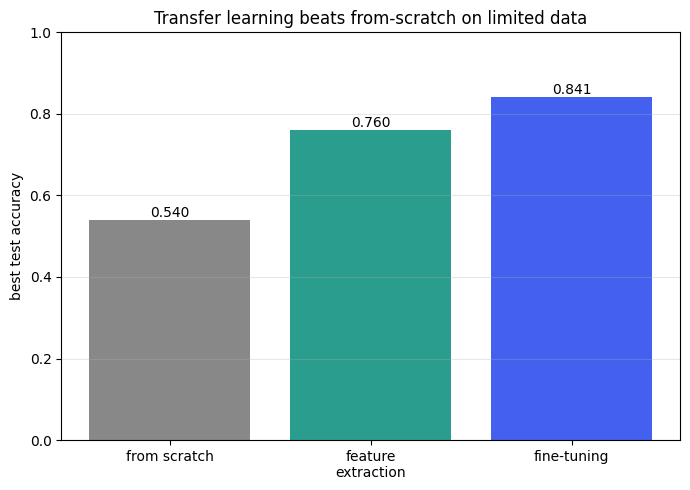

In [12]:
import numpy as np

FROM_SCRATCH_ACC = 0.54   # ~ the from-scratch CNN's test acc on this subset (C8/C14 baseline)

fe_best = max(fe_hist["test_acc"])
ft_best = max(ft_hist["test_acc"])
print(f"From-scratch CNN (baseline):   ~{FROM_SCRATCH_ACC:.3f}")
print(f"Transfer — feature extraction: {fe_best:.3f}")
print(f"Transfer — fine-tuning:        {ft_best:.3f}")

np.save(f"{RESULTS_DIR}/tl_feature_extraction.npy", np.array(fe_hist["test_acc"]))
np.save(f"{RESULTS_DIR}/tl_fine_tuning.npy",        np.array(ft_hist["test_acc"]))

# Bar chart: from-scratch vs the two transfer regimes.
labels = ["from scratch", "feature\nextraction", "fine-tuning"]
vals = [FROM_SCRATCH_ACC, fe_best, ft_best]
plt.figure(figsize=(7, 5))
bars = plt.bar(labels, vals, color=["#888", "#2a9d8f", "#4361ee"])
plt.ylabel("best test accuracy")
plt.title("Transfer learning beats from-scratch on limited data")
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.3)
for bar, v in zip(bars, vals):
    plt.text(bar.get_x()+bar.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/c16_transfer_learning.png", dpi=120)
plt.show()

### C16 · Concept check (interview-level)

**Q1. Feature extraction trains only ~0.05% of the parameters (the head) yet beat the from-scratch CNN by 22 points. How can training so few parameters do so much?**

Because the frozen 99.95% isn't idle — it's doing the hard part. ResNet-18's convolutional backbone was
trained on 1.2M ImageNet images to extract a rich, general visual representation: edges and textures in
early layers, shapes and object parts deeper. Those features transfer to CIFAR because "what makes an
image" is largely task-independent at the low and mid levels. So feature extraction reuses that
enormous amount of learned visual knowledge for free and only needs to learn the *last* mapping —
"given these high-level features, which of my 10 classes is it?" That's a simple linear problem the head
can solve from a few thousand examples. From scratch, the network would have to learn the entire feature
hierarchy from only 4,000 images — far too little — which is exactly why it caps at 54%. The parameter
count being trained is small, but it sits on top of a feature extractor worth millions of images of
training.

**Q2. Fine-tuning (unfreezing layer4) beat feature extraction (0.841 vs 0.760). Why unfreeze only the LAST block, and why the small learning rate?**

Early layers learn generic features (edges, textures) that are useful for essentially any image task, so
they need no change — freezing them preserves that knowledge and avoids overfitting on limited data. The
*late* layers (layer4) learn the most task-specific, high-level features, which were tuned for ImageNet's
1000 classes and benefit from adapting to CIFAR's specifics — so that's the block worth unfreezing. The
small learning rate (1e-4, 10× smaller than the head's) is critical: the pretrained weights are already
good, so you want to gently *nudge* them, not overwrite them. A large learning rate would take big
destructive steps and wash out the very ImageNet knowledge you're trying to keep — often making
fine-tuning *worse* than feature extraction. Unfreeze late, step gently: adapt without forgetting.

**Q3. We used ImageNet normalization stats and resized to 224, not CIFAR's own stats at 32×32. Why does matching the pretrained model's input conditions matter?**

Because a pretrained model's weights are calibrated to the exact input distribution it was trained on.
ResNet-18's first convolution expects inputs normalized with ImageNet's mean/std; feeding CIFAR-normalized
(or raw) pixels shifts the input distribution away from what every downstream layer assumes, degrading
the quality of the features it produces — you'd be handing the network inputs it was never designed to
read. Similarly, ImageNet models were trained on ~224px images, and their receptive fields and pooling
are sized for that scale; at 32×32 the spatial information is so small by the time it reaches the deep
layers that the pretrained features can't operate properly. Resizing up to 224 and using ImageNet
normalization makes CIFAR images "look like" the data the backbone expects, so the transferred features
are valid. Matching input conditions is part of transfer learning, not an optional detail — mismatched
preprocessing is a common reason transfer learning underperforms in practice.